# Lab 8 – RNN, LSTM and Attention
COS30018 Intelligent Systems · Anas Al Azad

**Task:** every example is a sequence of T random digits and the label is the **first** digit, so a model only gets it right if it remembers step 1 until the last step. Chance = 0.10.

* **Part 1** – how the gradient shrinks over 50 steps (RNN / LSTM / GRU)
* **Part 2** – train RNN / LSTM / GRU for T = 5, 10, 20, 60 (3 seeds each) + the 128-unit experiment
* **Part 3** – self-attention for T = 10, 20, 60, where it looks, and the ablation without positional encoding
* then: results table, checkpoint answers, and one extra experiment of mine

All the code below is from the lab sheet. The only things I added are marked `# (my addition)` – saving the plots for my summary and keeping the accuracies so I can build the results table at the end.

## 3. Setup

In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import os, time                                      # (my addition)
os.makedirs("figures", exist_ok=True)                # (my addition) plots for the summary go here
print("torch", torch.__version__, "| threads:", torch.get_num_threads())   # (my addition)

def make_data(n, T, seed):
    g = torch.Generator().manual_seed(seed)
    X = torch.randint(0, 10, (n, T), generator=g)   # n sequences of T digits
    return X, X[:, 0].clone()                        # label = the FIRST digit

X, y = make_data(3, 10, seed=0)
print(X)
print(y)

torch 2.14.1+cu130 | threads: 4
tensor([[4, 9, 3, 0, 3, 9, 7, 3, 7, 3],
        [1, 6, 6, 9, 8, 6, 6, 8, 4, 3],
        [6, 9, 1, 4, 4, 1, 9, 9, 9, 0]])
tensor([4, 1, 6])


3 rows of 10 digits and 3 labels – each label is the first digit of its row ✔

## 4. Part 1: Vanishing gradients
The gradient at step t = how much the last hidden state changes if you nudge the input at step t.

RNN gradient at last step / first step = 1.5e+13
LSTM gradient at last step / first step = 7.8e+10
GRU gradient at last step / first step = 2.8e+10


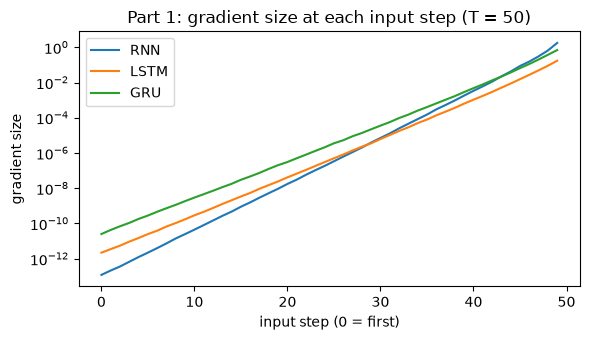

In [2]:
def grad_per_step(layer, T=50):
    x = torch.randn(64, T, 16, requires_grad=True)   # random input sequence
    h, _ = layer(x)                                   # h: hidden state at every step
    g, = torch.autograd.grad(h[:, -1].pow(2).sum(), x)
    return g.norm(dim=-1).mean(0).detach()            # gradient size at each input step

grad_ratio = {}                                       # (my addition)
plt.figure(figsize=(6, 3.5))
for name, Layer in [("RNN", nn.RNN), ("LSTM", nn.LSTM), ("GRU", nn.GRU)]:
    torch.manual_seed(0)
    n = grad_per_step(Layer(16, 32, batch_first=True))
    plt.semilogy(n.numpy(), label=name)
    print(name, "gradient at last step / first step = %.1e" % (n[-1] / n[0]))
    grad_ratio[name] = (n[-1] / n[0]).item()          # (my addition)
plt.xlabel("input step (0 = first)"); plt.ylabel("gradient size")
plt.title("Part 1: gradient size at each input step (T = 50)")   # (my addition)
plt.legend(); plt.tight_layout()
plt.savefig("figures/8_1_gradient_plot.png", dpi=150)            # (my addition)
plt.show()

## 5. Part 2: RNN, LSTM and GRU
Same model except for the recurrent layer; predicts the first digit from the **last** hidden state. 15 epochs, chance = 0.10.

In [3]:
results = {}                                         # (my addition) (name, T) -> list of accuracies

class RNNNet(nn.Module):
    def __init__(self, kind, units=32):
        super().__init__()
        self.emb = nn.Embedding(10, 16)
        Layer = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = Layer(16, units, batch_first=True)
        self.out = nn.Linear(units, 10)

    def forward(self, x):
        h, _ = self.rnn(self.emb(x))
        return self.out(h[:, -1])                     # predict from the last step only

def train_eval(model, T, seed, epochs=15):
    Xtr, ytr = make_data(5000, T, seed)
    Xte, yte = make_data(1000, T, seed + 1000)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), 64):
            idx = perm[i:i + 64]
            opt.zero_grad()
            loss_fn(model(Xtr[idx]), ytr[idx]).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

def run(name, make, Ts, seeds=(0, 1, 2), epochs=15):
    for T in Ts:
        accs = []
        for s in seeds:
            torch.manual_seed(s)
            accs.append(train_eval(make(T), T, s, epochs))
        print(f"{name:10s} T={T:3d} mean={np.mean(accs):.2f}      runs={np.round(accs, 2)}")
        results[(name, T)] = accs                     # (my addition)

3 models × 4 lengths × 3 seeds (the sheet says ~5 minutes):

In [4]:
t0 = time.time()                                     # (my addition)
for kind in ["rnn", "lstm", "gru"]:
    run(kind, lambda T: RNNNet(kind), [5, 10, 20, 60])
print(f"took {time.time() - t0:.0f}s")                # (my addition)

rnn        T=  5 mean=1.00      runs=[1. 1. 1.]
rnn        T= 10 mean=0.66      runs=[0.79 1.   0.19]
rnn        T= 20 mean=0.10      runs=[0.1  0.1  0.09]
rnn        T= 60 mean=0.10      runs=[0.09 0.09 0.1 ]
lstm       T=  5 mean=1.00      runs=[1. 1. 1.]
lstm       T= 10 mean=0.96      runs=[1.   0.87 1.  ]
lstm       T= 20 mean=0.47      runs=[0.32 0.18 0.9 ]
lstm       T= 60 mean=0.09      runs=[0.08 0.1  0.08]
gru        T=  5 mean=1.00      runs=[1. 1. 1.]
gru        T= 10 mean=1.00      runs=[1. 1. 1.]
gru        T= 20 mean=0.10      runs=[0.1  0.1  0.09]
gru        T= 60 mean=0.09      runs=[0.09 0.1  0.08]
took 212s


### Experiment: change one parameter – hidden layer 32 → 128 units, T = 20 again

In [5]:
for kind in ["rnn", "lstm", "gru"]:
    run(kind + "-128", lambda T: RNNNet(kind, units=128), [20])

rnn-128    T= 20 mean=0.77      runs=[0.51 0.82 1.  ]
lstm-128   T= 20 mean=0.59      runs=[1.   0.57 0.2 ]
gru-128    T= 20 mean=1.00      runs=[1. 1. 1.]


## 6. Part 3: Self-attention
No recurrence – every position looks at every other position directly. Positional encoding adds a fixed sin/cos pattern so each position gets its own tag.

In [6]:
def pos_enc(T, d):
    pos = torch.arange(T).unsqueeze(1).float()
    i = torch.arange(d).unsqueeze(0)
    angle = pos / torch.pow(10000.0, (2 * (i // 2)).float() / d)
    return torch.where(i % 2 == 0, torch.sin(angle), torch.cos(angle))

class AttnNet(nn.Module):
    def __init__(self, T, use_pos=True, d=32):
        super().__init__()
        self.use_pos = use_pos
        self.emb = nn.Embedding(10, d)
        self.register_buffer("pe", pos_enc(T, d))
        self.attn = nn.MultiheadAttention(d, 2, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, d))
        self.out = nn.Linear(d, 10)

    def forward(self, x, return_w=False):
        h = self.emb(x)
        if self.use_pos:
            h = h + self.pe                           # add position information
        a, w = self.attn(h, h, h, need_weights=True, average_attn_weights=False)
        h = self.ln1(h + a)
        h = self.ln2(h + self.ff(h))
        o = self.out(h[:, -1])                        # last position makes the prediction
        return (o, w) if return_w else o

run("attn", lambda T: AttnNet(T), [10, 20, 60])

attn       T= 10 mean=1.00      runs=[1. 1. 1.]
attn       T= 20 mean=1.00      runs=[1. 1. 1.]
attn       T= 60 mean=1.00      runs=[1. 1. 1.]


### Where does the model look?
Train one model at T = 20, average the last position's attention weights over 200 sequences, plot both heads.

accuracy: 1.0


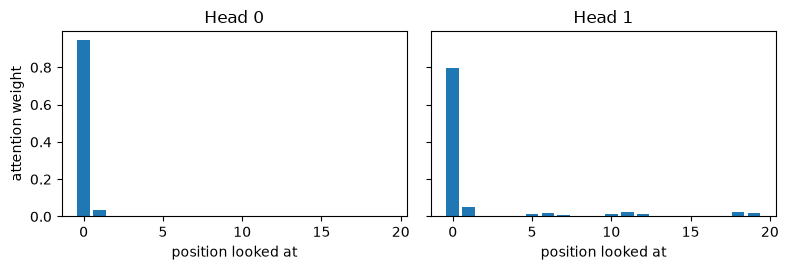

weight on position 0: [0.95, 0.8]


In [7]:
T = 20
torch.manual_seed(0)
model = AttnNet(T)
print("accuracy:", train_eval(model, T, seed=0))

Xs, _ = make_data(200, T, seed=5)
model.eval()
with torch.no_grad():
    _, w = model(Xs, return_w=True)                  # shape: (200, heads, T, T)
last = w[:, :, -1, :].mean(0)                        # last position, averaged over 200 sequences

fig, axes = plt.subplots(1, 2, figsize=(8, 2.8), sharey=True)
for h in range(2):
    axes[h].bar(range(T), last[h].numpy())
    axes[h].set_title(f"Head {h}"); axes[h].set_xlabel("position looked at")
axes[0].set_ylabel("attention weight")
plt.tight_layout()
plt.savefig("figures/8_2_attention_plot.png", dpi=150)          # (my addition)
plt.show()
print("weight on position 0:", [round(last[h][0].item(), 2) for h in range(2)])   # (my addition)

### Ablation: remove positional encoding

In [8]:
run("attn_nopos", lambda T: AttnNet(T, use_pos=False), [10, 30])

attn_nopos T= 10 mean=0.26      runs=[0.28 0.25 0.26]
attn_nopos T= 30 mean=0.18      runs=[0.19 0.18 0.19]


## Results table (Parts 2 and 3) – mean test accuracy over 3 seeds (chance = 0.10)

In [9]:
# (my addition) build the model x T table from everything above
import pandas as pd
order = [("rnn", "RNN"), ("lstm", "LSTM"), ("gru", "GRU"),
         ("rnn-128", "RNN (128 units)"), ("lstm-128", "LSTM (128 units)"), ("gru-128", "GRU (128 units)"),
         ("attn", "Attention"), ("attn_nopos", "Attention, no pos. enc.")]
Ts = sorted({T for (_, T) in results})
table = pd.DataFrame(index=[label for _, label in order], columns=[f"T={T}" for T in Ts], dtype=object)
for key, label in order:
    for T in Ts:
        if (key, T) in results:
            table.loc[label, f"T={T}"] = f"{np.mean(results[(key, T)]):.2f}"
table = table.fillna("–")
table.to_csv("results_table.csv")
table

,T=5,T=10,T=20,T=30,T=60
RNN,1.00,0.66,0.10,–,0.10
LSTM,1.00,0.96,0.47,–,0.09
GRU,1.00,1.00,0.10,–,0.09
RNN (128 units),–,–,0.77,–,–
LSTM (128 units),–,–,0.59,–,–
GRU (128 units),–,–,1.00,–,–
Attention,–,1.00,1.00,–,1.00
"Attention, no pos. enc.",–,0.26,–,0.18,–


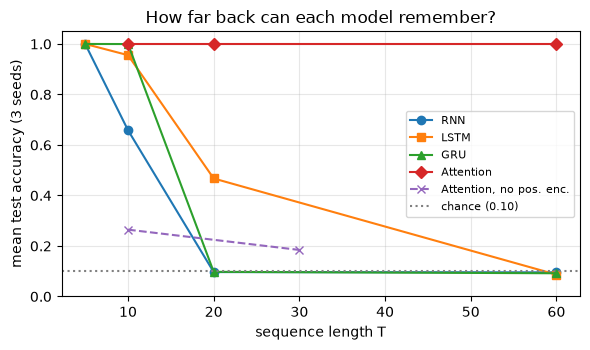

In [10]:
# (my addition) accuracy vs sequence length
plt.figure(figsize=(6, 3.6))
for key, label, style in [("rnn", "RNN", "o-"), ("lstm", "LSTM", "s-"), ("gru", "GRU", "^-"),
                          ("attn", "Attention", "D-"), ("attn_nopos", "Attention, no pos. enc.", "x--")]:
    pts = sorted((T, np.mean(a)) for (k, T), a in results.items() if k == key)
    plt.plot([p[0] for p in pts], [p[1] for p in pts], style, label=label)
plt.axhline(0.10, color="grey", ls=":", label="chance (0.10)")
plt.xlabel("sequence length T"); plt.ylabel("mean test accuracy (3 seeds)")
plt.title("How far back can each model remember?")
plt.ylim(0, 1.05); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("figures/8_3_accuracy_vs_T.png", dpi=150)
plt.show()

In [11]:
# (my addition) save everything for the summary / worklog
import json
json.dump({"grad_ratio": grad_ratio,
           "results": {f"{k}|{T}": v for (k, T), v in results.items()},
           "attention_weight_pos0": [round(last[h][0].item(), 4) for h in range(2)]},
          open("results.json", "w"), indent=1)
print(json.dumps(grad_ratio, indent=1))

{
 "RNN": 14588839985152.0,
 "LSTM": 78463074304.0,
 "GRU": 27507212288.0
}


## 7. Checkpoint questions
*(answers written after looking at my results – see the cell below)*

**Q1. In Part 1, which input step has the smallest gradient? What does this mean for learning the first digit?**

Step 0 – the very first input – has the smallest gradient for all three layers: the gradient at the last step is about 1.5×10¹³ times bigger for the RNN, 7.8×10¹⁰ for the LSTM and 2.8×10¹⁰ for the GRU. But the first digit is exactly what the label is, so the weights get almost no training signal about how to store it. That's why the plain RNN drops to chance (0.10) from T = 20, while the gated LSTM/GRU hold on a bit longer (fine at T = 10).

**Q2. In Part 2, runs with the same settings give different accuracy. What does this tell you about training RNNs on long sequences?**

Only the seed changes (initial weights + data order), yet the results jump around a lot: the RNN at T = 10 got 0.79 / 1.00 / 0.19 and the LSTM at T = 20 got 0.32 / 0.18 / 0.90. Because the gradient from the early steps is so tiny, whether a run ever finds the link between step 1 and the label is basically luck. So training RNNs on long sequences is unstable – you need several seeds and should look at the spread, not just one number (or even just the mean).

**Q3. In Part 3, accuracy drops when you remove positional encoding. Why?**

Self-attention on its own doesn't know about order – it compares every step with every other step by content only, so without positional encoding the sequence is just a bag of digits and the model can't tell which one came first. The best it can do is guess the most common digit, which is right (count of that digit)/T of the time – I worked out that this gives ≈0.27 for T = 10 and ≈0.20 for T = 30 (cell below), which is basically the 0.26 and 0.18 I got. With positional encoding every step gets its own sin/cos tag, so the last position can look straight at position 0 (weights 0.95 / 0.80 in my plot) and gets 1.00.

In [12]:
# (my addition) checking my Q3 answer: without positions, the best possible strategy is
# "predict the most frequent digit in the sequence" -> correct with probability max_count / T
rng = np.random.default_rng(0)
for T in (10, 30):
    Xb = rng.integers(0, 10, size=(200_000, T))
    counts = np.stack([(Xb == d).sum(1) for d in range(10)], axis=1)
    best_possible = (counts.max(1) / T).mean()
    print(f"T = {T}: best order-blind accuracy = {best_possible:.3f} | my attn_nopos model = {np.mean(results[('attn_nopos', T)]):.2f}")

T = 10: best order-blind accuracy = 0.275 | my attn_nopos model = 0.26
T = 30: best order-blind accuracy = 0.197 | my attn_nopos model = 0.18


## My extra experiment: is it memory or just not enough training?
At T = 20 the plain models are around chance. If I give them more epochs (40 instead of 15), do they get there eventually?

In [13]:
# (my addition) same models, T = 20, 40 epochs instead of 15
t0 = time.time()
for kind in ["rnn", "lstm", "gru"]:
    run(kind + "-40ep", lambda T: RNNNet(kind), [20], epochs=40)
print(f"took {time.time() - t0:.0f}s")

rnn-40ep   T= 20 mean=0.55      runs=[0.57 0.1  1.  ]
lstm-40ep  T= 20 mean=0.93      runs=[0.89 0.91 1.  ]
gru-40ep   T= 20 mean=0.96      runs=[1.   0.88 1.  ]
took 123s


**What I got:** with 40 epochs instead of 15, at T = 20 the **LSTM goes from 0.47 → 0.93 and the GRU from 0.10 → 0.96**, while the RNN reaches 0.55 on average – but one of its 3 runs is still stuck at chance (0.10).

So at T = 20 it's partly a *training* problem, not only a memory limit: the gated models can learn the dependency, they just need many more updates to get past the tiny gradient from step 1. The plain RNN is still unreliable. I didn't try T = 60 with more epochs – based on Part 1 the gradient there is so small that I'd expect it to need far more training (or attention, which got 1.00 straight away).